In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('inventroy.db')

df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [3]:
#summarystatistics
df.describe().T


,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


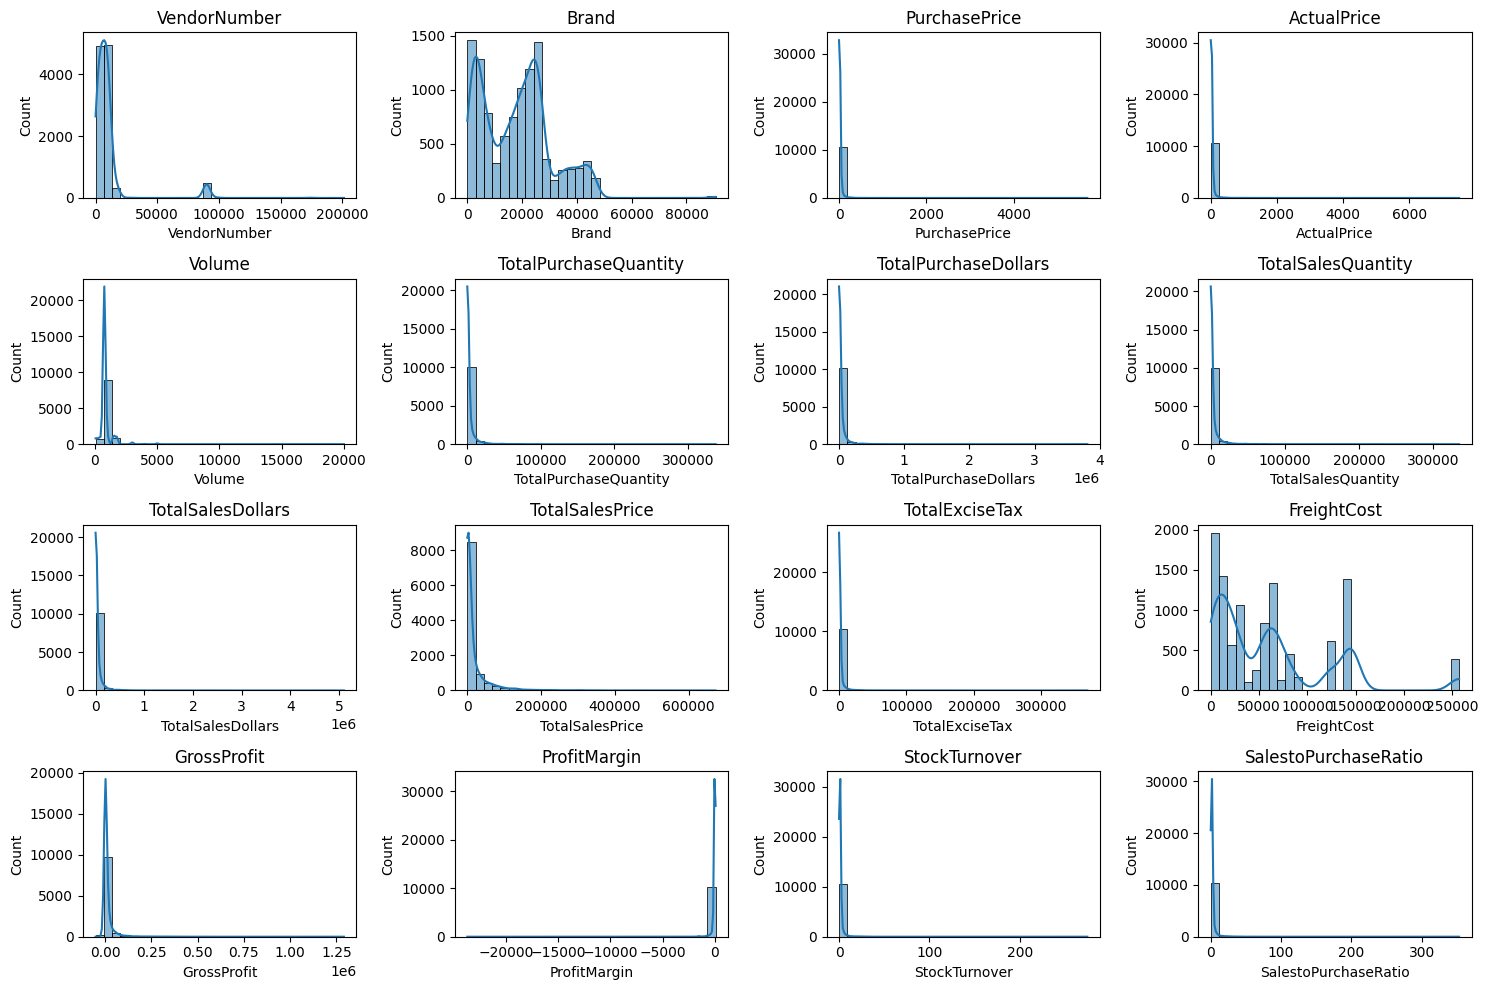

In [4]:
#Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #Adjust grid layout as needed
    sns.histplot(df[col], kde=True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

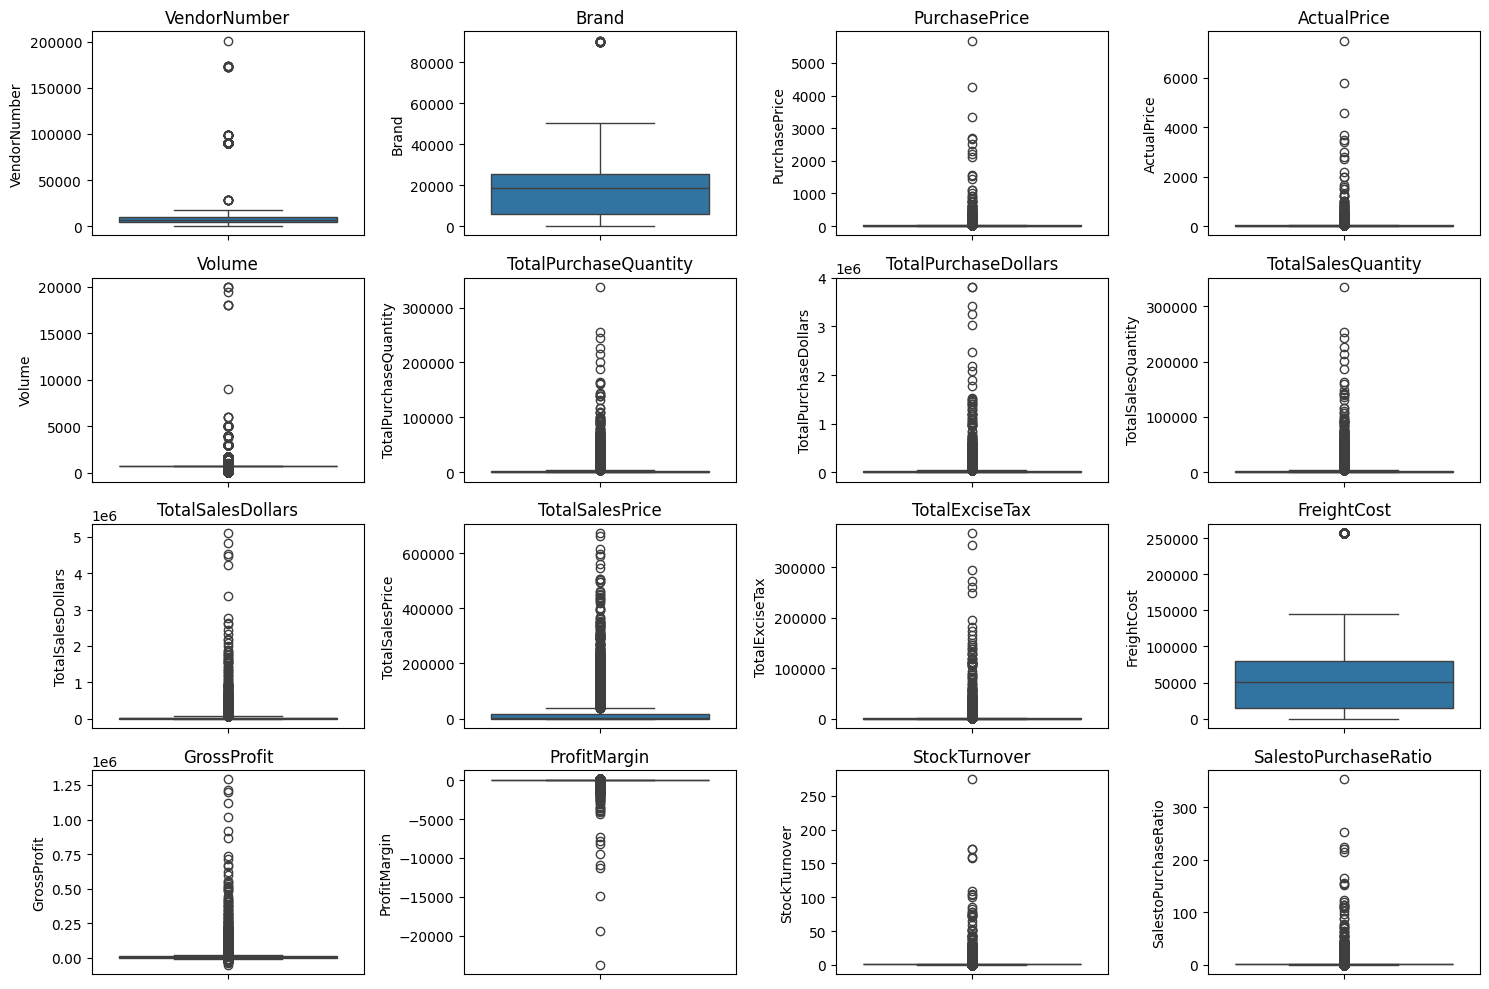

In [8]:
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #Adjust grid layout as needed
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [9]:
df = pd.read_sql_query("""
SELECT * FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity >0""", conn)


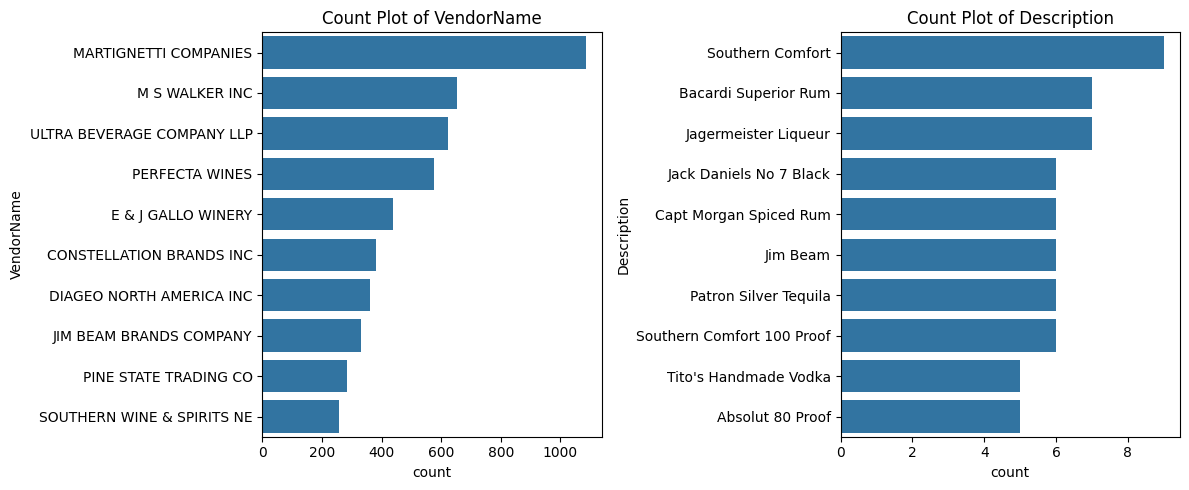

In [10]:
categorical_cols = ["VendorName","Description"]

plt.figure(figsize = (12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2, i+1) #Adjust grid layout as needed
    sns.countplot(df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

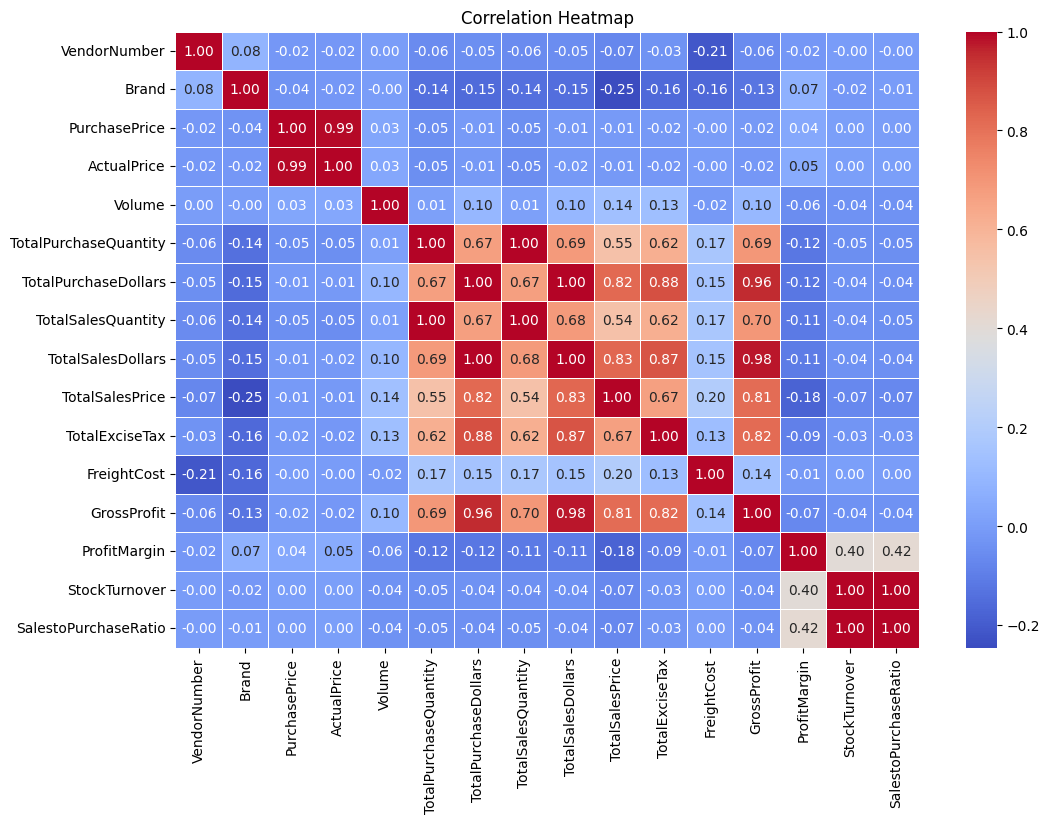

In [11]:
#co-relation
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot = True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [12]:
# Data Analysis
# Q1. Identify Brands that needs promotional or pircing adjustments which exhibit lower sales perfomrance but higher profit margins.
brand_performance=df.groupby("Description").agg({
     'TotalSalesDollars' :'sum',
     'ProfitMargin' : 'mean'}).reset_index()

In [13]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold= brand_performance['ProfitMargin'].quantile(0.85)

In [14]:
target_brands = brand_performance [
    (brand_performance["TotalSalesDollars"] <= low_sales_threshold) & 
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
    ]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


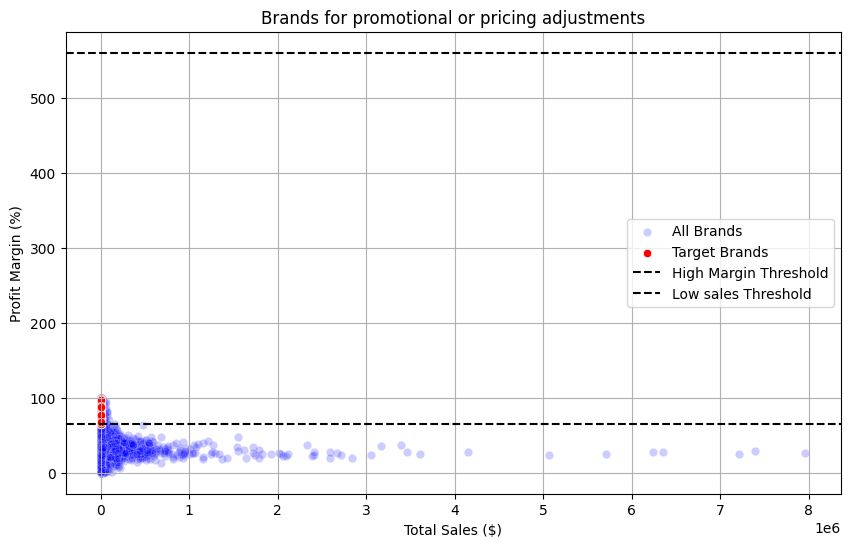

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x="TotalSalesDollars" , y='ProfitMargin', color='blue', label='All Brands', alpha = 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='Red', label ='Target Brands')

plt.axhline(high_margin_threshold, linestyle= '--', color= 'black', label='High Margin Threshold')
plt.axhline(low_sales_threshold, linestyle= '--', color= 'black', label='Low sales Threshold')

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for promotional or pricing adjustments')
plt.legend()
plt.grid(True)
plt.show()
                

In [16]:
def format_dollars(value):
    if value >= 1000000:
        return f"{value/1000000:.2f}M"
    elif value >1000:
        return f"{value / 1000:.2f}K"
    else:
        return str(value)

In [17]:
#Q2. Which Vendors and brands demonstarte the highest sales performance?

top_vendors = df.groupby("VendorName")['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby("Description")['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [18]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [19]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

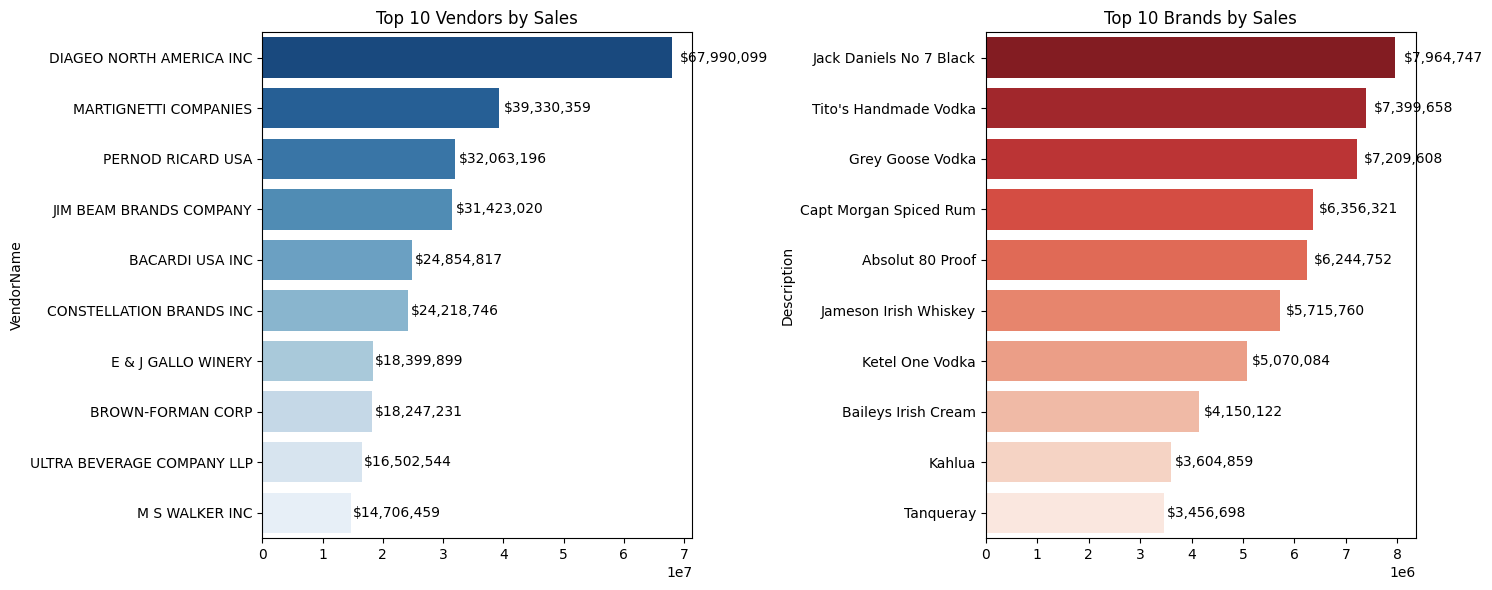

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the currency formatter function
def format_dollars(value):
    return f"${value:,.0f}"

# 2. Setup the figure layout
plt.figure(figsize=(15, 6))

# 3. Plot for Top 10 Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# 4. Plot for Top 10 Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha='left', va='center', fontsize=10, color='black')

# 5. Clean up layout and display
plt.tight_layout()
plt.show()


In [21]:
#Q3, Which vendros contribute the most to total purchase dollars?
vendor_performance=df.groupby("VendorName").agg({
    'TotalPurchaseDollars' : 'sum',
    'GrossProfit' : 'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()
vendor_performance.shape

(119, 4)

In [22]:
vendor_performance ['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100

In [23]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [24]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226","$17,892,873","$67,990,099",16.30
57,MARTIGNETTI COMPANIES,"$25,502,096","$13,828,264","$39,330,359",8.30
68,PERNOD RICARD USA,"$23,851,164","$8,212,032","$32,063,196",7.76
46,JIM BEAM BRANDS COMPANY,"$23,494,304","$7,928,716","$31,423,020",7.64
6,BACARDI USA INC,"$17,432,020","$7,422,797","$24,854,817",5.67
20,CONSTELLATION BRANDS INC,"$15,273,708","$8,945,038","$24,218,746",4.97
11,BROWN-FORMAN CORP,"$13,238,939","$5,008,291","$18,247,231",4.31
30,E & J GALLO WINERY,"$12,068,539","$6,331,360","$18,399,899",3.93
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,082","$5,335,463","$16,502,544",3.63
53,M S WALKER INC,"$9,764,313","$4,942,146","$14,706,459",3.18


In [25]:
top_vendors['PurchaseContribution%']

25     16.30
57      8.30
68      7.76
46      7.64
6       5.67
20      4.97
11      4.31
30      3.93
106     3.63
53      3.18
Name: PurchaseContribution%, dtype: float64

In [26]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,"$50,097,226","$17,892,873","$67,990,099",16.30,16.30
57,MARTIGNETTI COMPANIES,"$25,502,096","$13,828,264","$39,330,359",8.30,24.60
68,PERNOD RICARD USA,"$23,851,164","$8,212,032","$32,063,196",7.76,32.36
46,JIM BEAM BRANDS COMPANY,"$23,494,304","$7,928,716","$31,423,020",7.64,40.00
6,BACARDI USA INC,"$17,432,020","$7,422,797","$24,854,817",5.67,45.67
20,CONSTELLATION BRANDS INC,"$15,273,708","$8,945,038","$24,218,746",4.97,50.64
11,BROWN-FORMAN CORP,"$13,238,939","$5,008,291","$18,247,231",4.31,54.95
30,E & J GALLO WINERY,"$12,068,539","$6,331,360","$18,399,899",3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,"$11,167,082","$5,335,463","$16,502,544",3.63,62.51
53,M S WALKER INC,"$9,764,313","$4,942,146","$14,706,459",3.18,65.69


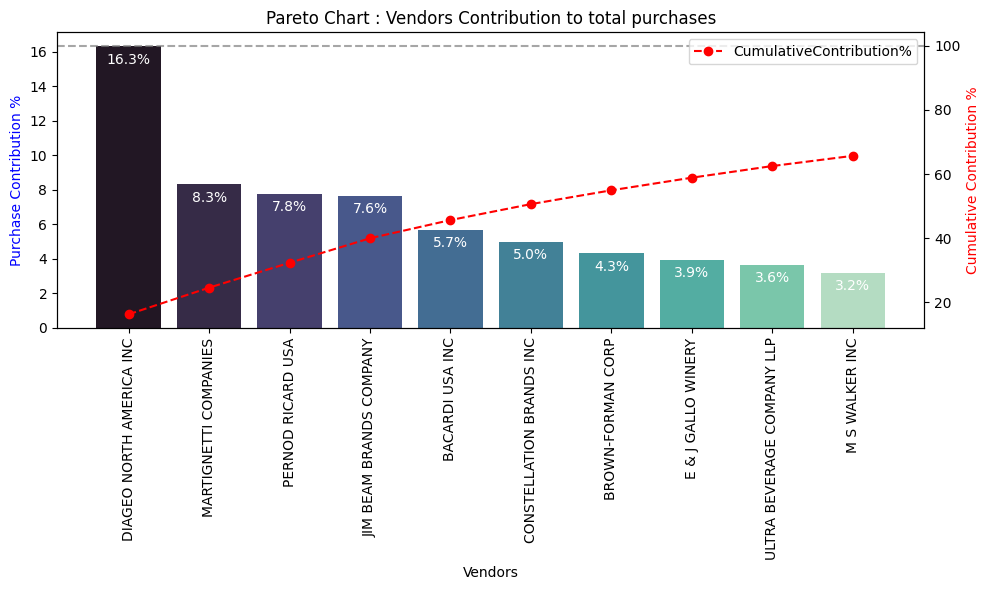

In [27]:
# 1. Ensure columns are accessible
# If VendorName is a column, we don't need .index
fig, ax1 = plt.subplots(figsize=(10,6))

# 2. Corrected Plotting: Use column names directly
sns.barplot(data=top_vendors, x='VendorName', y='PurchaseContribution%', palette='mako', ax=ax1)

# 3. Corrected Loop: Spelling fixed (enumerate), and accessing data safely
# We use top_vendors.reset_index(drop=True) to ensure clean integer positions for 'i'
plot_data = top_vendors.reset_index(drop=True)
for i, value in enumerate(plot_data['PurchaseContribution%']):
    ax1.text(i, value - 1, f"{value:.1f}%", ha='center', fontsize=10, color='white')

# 4. Line Plot for cumulative contribution
ax2 = ax1.twinx()
ax2.plot(plot_data['VendorName'], plot_data['Cumulative_Contribution%'], 
         color='red', marker='o', linestyle='dashed', label='CumulativeContribution%')

# 5. Formatting
ax1.set_xticklabels(plot_data['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart : Vendors Contribution to total purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [28]:
top_vendors.columns

Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%',
       'Cumulative_Contribution%'],
      dtype='str')

In [29]:
#Q How much of total procurement is dependent on the top-vendors?

print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 65.69%


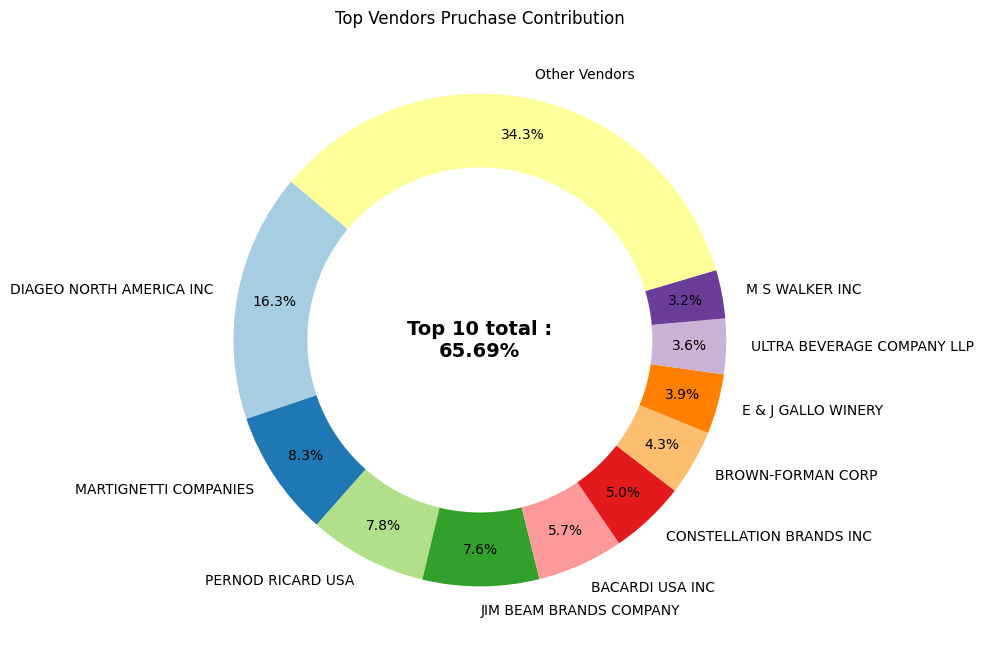

In [30]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

#Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

#Donut Chart
fig, ax= plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                  startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

#Draw a white circle in the center to create a donut effect
centre_circle = plt.Circle((0,0), 0.7, fc="white")
fig.gca().add_artist(centre_circle)

#Add total contribution annotation in the center
plt.text(0, 0, f"Top 10 total :\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top Vendors Pruchase Contribution")
plt.show()

In [31]:
top_vendors.columns

Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%',
       'Cumulative_Contribution%'],
      dtype='str')

In [32]:
#Q. Does Purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [33]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])


In [34]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


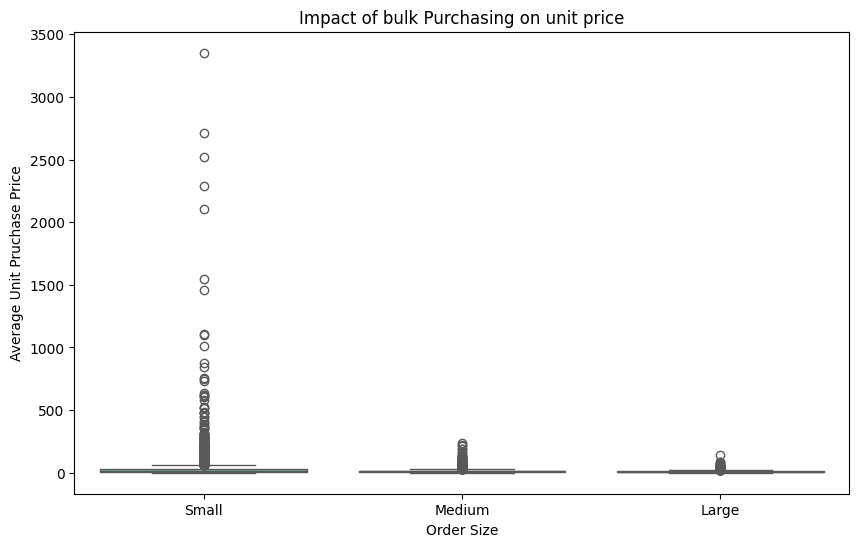

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice', palette='Set2')
plt.title('Impact of bulk Purchasing on unit price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Pruchase Price')
plt.show()

In [36]:
#Which Vednors have low inventory turnover, indicating excess stock and slow moving products?
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [37]:
#What is the 95% confidence intervals for profit margins of top_performing and low_ performaing vendors
top_threshold=df['TotalSalesDollars'].quantile(0.75)
low_threshold=df['TotalSalesDollars'].quantile(0.25)

In [38]:
top_vendors= df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors= df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [39]:
def confidence_intercal(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1+ confidence) / 2, df=len(data) -1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error


NameError: name 'top_lower' is not defined

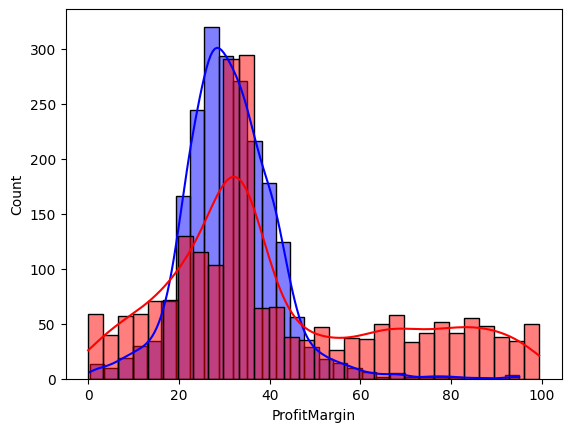

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the histograms
# kde=True adds the smoothed density curve, bins=30 sets the resolution
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")

# 2. Add vertical lines for confidence intervals and means
# axvline creates the vertical lines at specific x-coordinates
# 'linestyle="--"' creates dashed lines for the bounds, while '-' is used for the mean
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# 3. Finalize the plot formatting
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [1]:
import os
print(os.getcwd())

C:\Windows\system32\Vendor_performancec_analysis


In [3]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('inventroy.db')
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())
conn.close()


[('vendor_invoice',), ('vendor_sales_summary',), ('begin_inventory',), ('end_inventory',), ('purchases',), ('purchase_prices',), ('sales',)]


In [5]:
import os
print(os.path.abspath('inventroy.db'))


C:\Windows\system32\Vendor_performancec_analysis\inventroy.db
